# 

![Banner](images.jpg)

# Clean Energy Market Segmentation and CO₂ Emissions Analysis with Forecasting and Regression


## Business Understanding

### Project Overview

Climate change is a major global challenge driven largely by greenhouse gas emissions, particularly carbon dioxide (CO₂). However, emission patterns differ significantly across countries due to differences in population, economic activity, energy consumption, and dependence on fossil fuels.

Understanding both the *current emission characteristics of countries* and *how emissions are likely to change over time* can support governments, environmental organizations, and policymakers in developing more targeted climate strategies.

This project uses historical country-level CO₂ emissions data to examine emission patterns through two complementary machine learning approaches: *classification and time-series forecasting*.

### Business Problem

Countries have different levels and patterns of CO₂ emissions, making it difficult to apply the same environmental strategies across all regions. In addition, historical emission trends alone do not provide sufficient information about how emissions may develop in the future.

Therefore, there is a need to:

1. Identify and classify countries according to meaningful CO₂ emission characteristics using demographic, economic, energy, and emission-related factors.
2. Analyze historical CO₂ emission patterns over time and forecast future emission trends.

Combining classification and time-series forecasting provides both a *comparative view of emission profiles* and a *forward-looking view of how emissions may change over time*.

### Project Objectives

The main objective of this project is to use historical CO₂ emissions data to understand emission patterns across countries and predict future emission trends.

The specific objectives are:

- Explore historical CO₂ emission patterns across countries and over time.
- Identify economic, demographic, energy, and emission-related factors associated with differences in CO₂ emissions.
- Develop a *classification model* to categorize country observations according to defined CO₂ emission levels or profiles.
- Develop a *time-series forecasting model* to predict future CO₂ emissions using historical emission patterns.
- Compare model performance using appropriate classification and forecasting evaluation metrics.
- Generate insights that can support environmental planning and climate-related decision-making.

### The Solution Could Help

The analysis could support:

- **Clean-energy companies** in identifying groups of markets with similar energy and emissions characteristics.
- **Investors** in screening countries for further clean-energy investment analysis.
- **Policymakers** in understanding different emissions and energy challenges across countries.
- **Development organizations and NGOs** in targeting clean-energy programs toward groups of countries with similar needs.
- **Environmental organizations and researchers** in studying patterns in carbon intensity, energy consumption, and fossil-fuel dependence.

### Modeling Approach

The project will use two modeling approaches:

*1. Classification*

Classification models will be used to categorize observations into defined CO₂ emission classes. Relevant economic, demographic, energy, and emission-related variables will be evaluated as potential predictors.

Classification performance will be evaluated using metrics such as *accuracy, precision, recall, F1-score, and the confusion matrix*.

*2. Time-Series Forecasting*

Time-series models will be used to analyze historical CO₂ emission trends and forecast future emissions. Since the dataset contains annual observations from *1950 to 2024*, the temporal ordering of observations will be preserved during model development and evaluation.

Forecasting performance will be evaluated using appropriate error metrics such as *Mean Absolute Error (MAE)* and *Root Mean Squared Error (RMSE)*.

### Expected Outcome

The project is expected to produce:

- A clearer understanding of how CO₂ emissions differ across countries.
- Identification of important factors associated with emission levels.
- A classification model capable of distinguishing defined emission categories.
- A time-series model capable of forecasting future CO₂ emission trends.
- Actionable insights into historical and potential future emission patterns that can support climate planning and policy decisions.

## Data Understanding

## Data Source

The project will primarily use the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions dataset**.

The dataset provides historical country-level information on:

- CO₂ emissions
- CO₂ emissions growth
- CO₂ per capita
- Carbon intensity of GDP
- Population
- GDP
- Primary energy consumption
- Energy consumption per capita
- Energy intensity
- Coal emissions
- Oil emissions
- Gas emissions
- Cement emissions
- Flaring emissions
- Land-use change emissions


In [62]:
# Importing the neccesary libraries
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Loading the dataset
df = pd.read_csv('owid-co2-data.csv')
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Checking the shape
df.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [65]:
# Checking the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It looks like there are missing data in the dataset.

In [66]:
# Checking for missing data
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percent': df.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

In cleaning of this dataset, we have to be careful in how we will clean it because of its large number of missing values.

In [67]:
# Checking the column names
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [68]:
# Checking the decsription of the dataset
describe = df.describe()
describe

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

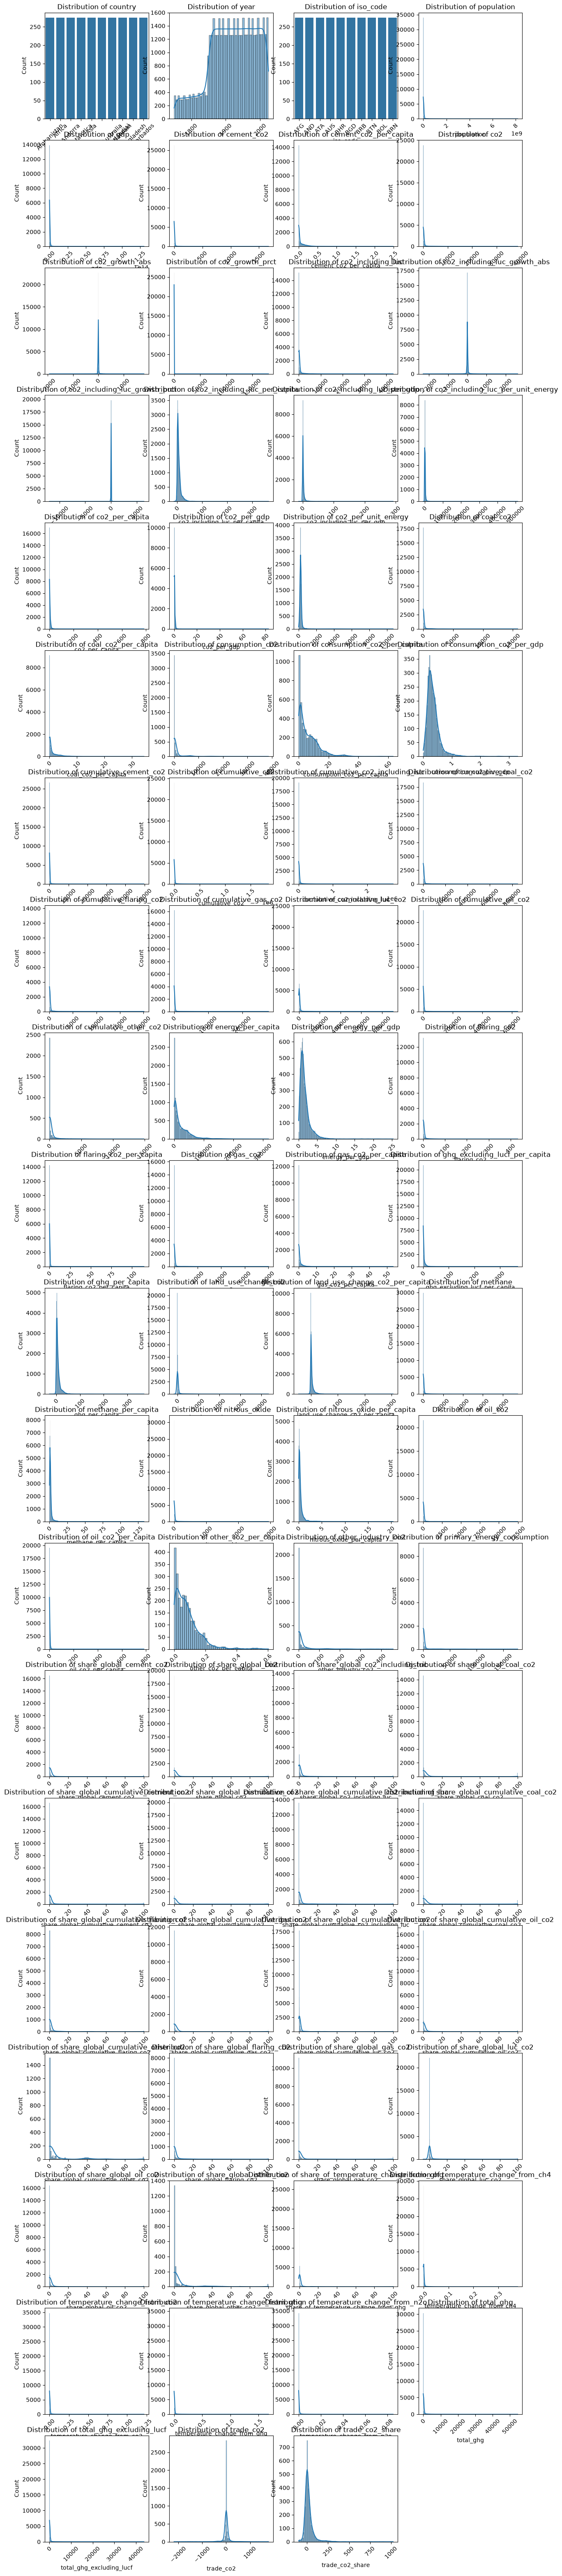

In [69]:
# Plotting the distribution of the column of the df dataset
num_cols = len(df.columns)
n_cols_per_row = 4
n_rows = (num_cols+n_cols_per_row - 1) // n_cols_per_row

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols_per_row, i+1)

    # Plotting numerical variables
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
# Plotting categorical variables
    else:
        top_cats = df[col].value_counts().iloc[:10]
        sns.barplot(x=top_cats.index, y=top_cats.values)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)

#plt.tight_layout()
#plt.show()

The distribution of the dataset is skewed. Median imputation will be used where necessary.

In [70]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    89.213086
1751    91.931919
1752    91.931919
1753    91.931919
1754    91.931919
1755    91.931919
1756    91.931919
1757    91.931919
1758    91.931919
1759    91.931919
1760    88.770999
1761    91.931919
1762    91.931919
1763    91.931919
1764    91.931919
1765    91.931919
1766    91.931919
1767    91.931919
1768    91.931919
1769    91.931919
1770    88.770999
1771    91.931919
1772    91.931919
1773    91.931919
1774    91.931919
1775    91.931919
1776    91.931919
1777    91.931919
1778    91.931919
1779    91.931919
1780    88.770999
1781    91.931919
1782    91.931919
1783    91.931919
1784    91.931919
1785    91.242938
1786    91.112560
1787    91.112560
1788    91.112560
1789    91.112560
1790    87.722729
1791    91.112560
1792    90.705128
1793    90.619658
1794    90.619658
1795    90.619658
1796    90.619658
1797    90.619658
1798    90.619658
1799    90.619658
1800    86.579818
1801    86.579818
1802    86.237981
1803    86.579818
1804    86.406186
1805 

We will keep years from 1950 onwards as it crosses the threshold of missing values

## Data Preprocessing

### Steps in the data preprocessing pipeline
0. Ensure the data type of year is datetime
1. Keep years from 1950 onwards
2. Keep columns with 50% or less missing values
3. Impute missing numeric values using median
4. Define continents
5. Define income groups
6. Countries / territories
7. Continents
8. Income groups
9. Other aggregates

In [ ]:
# Preprocessing pipeline
def preprocessing_pipeline(data):

    # Make a copy of the original dataset
    data = data.copy()
    
    # 0. Ensure the 'year' column is of datetime type
    data['year'] = pd.to_datetime(data['year'], format='%Y').dt.year

    # 1. Keep years from 1950 onwards
    data = data[data["year"] >= 1950].copy()

    # 2. Keep columns with 50% or less missing values
    data = data.loc[:, data.isnull().mean() <= 0.5].copy()

    # 3. Impute missing numeric values using median
    numeric_columns = data.select_dtypes(include="number").columns

    for col in numeric_columns:
        data[col] = data[col].fillna(data[col].median())

    # 4. Define continents
    continents = [
        "Africa",
        "Asia",
        "Europe",
        "North America",
        "South America",
        "Oceania"
    ]

    # 5. Define income groups
    income_groups = [
        "High-income countries",
        "Upper-middle-income countries",
        "Lower-middle-income countries",
        "Low-income countries",
        'Least developed countries (Jones et al.)'
    ]
    world = ["World"]
    # 6. Countries / territories
    data_countries = data[
        data["iso_code"].notna()
    ].copy()

    # 7. Continents
    data_continents = data[
        data["country"].isin(continents)
    ].copy()

    # 8. Income groups
    data_income_groups = data[
        data["country"].isin(income_groups)
    ].copy()

    # 9. Other aggregates
    data_region_group_entities= data[
        data["iso_code"].isna()
        & ~data["country"].isin(continents)
        & ~data["country"].isin(income_groups)
        & ~data["country"].isin(world)
    ].copy()

    # Return all datasets
    return (
        data,
        data_countries,
        data_continents,
        data_income_groups,
        data_region_group_entities
    )

# Calling the preprocessing_pipeline function
df_cleaned, df_countries, df_continents, df_income_groups, df_region_group_entities = preprocessing_pipeline(df)

Based on earlier analysis, we:

- Kept data from 1950 onwards

- Dropped columns with missing values exceeding the threshold 

- Used median imputation as the distribution is skewed

- We separated the dataset to categories from step 4 to step 9

In [ ]:
# Displaying df_countries
print("Countries/Territories:",
      df_countries["country"].nunique())

# Displaying df_continent
print("Continents:",
      df_continents["country"].nunique())

# Displaying df_income_groups
print("Income Groups:",
      df_income_groups["country"].nunique())

# Displaying df_region_group_entities
print("Other Aggregates:",
      df_region_group_entities["country"].nunique())

Countries/Territories: 218
Continents: 6
Income Groups: 5
Other Aggregates: 24


Unique values in the country column: 
* 218 Countries/Territories: 
* 6 Continents
* 4 Income Groups
* 24 region/group entities

In [ ]:
# Checking the unique names of the countries from df_coutries
df_countries["country"].unique()

<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
             'Andorra',              'Angola',            'Anguilla',
          'Antarctica', 'Antigua and Barbuda',           'Argentina',
             'Armenia',
 ...
             'Uruguay',          'Uzbekistan',             'Vanuatu',
             'Vatican',           'Venezuela',             'Vietnam',
   'Wallis and Futuna',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 218, dtype: str

In [ ]:
# Checking the unique names of the entities from df_region_group_entities
df_region_group_entities['country'].unique()

<StringArray>
[                'Africa (GCP)',                   'Asia (GCP)',
 'Asia (excl. China and India)',        'Central America (GCP)',
                 'Europe (GCP)',         'Europe (excl. EU-27)',
         'Europe (excl. EU-28)',          'European Union (27)',
          'European Union (28)',       'International aviation',
       'International shipping',                       'Kosovo',
            'Kuwaiti Oil Fires',      'Kuwaiti Oil Fires (GCP)',
            'Middle East (GCP)',               'Non-OECD (GCP)',
          'North America (GCP)',    'North America (excl. USA)',
                   'OECD (GCP)',          'OECD (Jones et al.)',
                'Oceania (GCP)',               'Ryukyu Islands',
         'Ryukyu Islands (GCP)',          'South America (GCP)']
Length: 24, dtype: str

In [ ]:
# Getting the column names from df_cleaned dataset
cleaned_cols = df_cleaned.columns

# check cleaned_cols against original df columns
original_cols = df.columns
# check for any columns that are in the original df but not in the cleaned df
missing_cols = [col for col in original_cols if col not in cleaned_cols]
print(missing_cols)

['consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_gas_co2', 'cumulative_other_co2', 'energy_per_gdp', 'gas_co2', 'gas_co2_per_capita', 'other_co2_per_capita', 'other_industry_co2', 'share_global_cumulative_gas_co2', 'share_global_cumulative_other_co2', 'share_global_gas_co2', 'share_global_other_co2', 'trade_co2', 'trade_co2_share']


These columns were removed due to exceeding the missing value threshold.

## Get the value counts for each column with normalize true to have it in percentile.

In [76]:
# Get percentage value counts for each column
for column in df_cleaned.columns:
    print(
        df_cleaned[column]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
        .head(5)
    )

country
Afghanistan     0.4
Africa          0.4
Africa (GCP)    0.4
Albania         0.4
Algeria         0.4
Name: proportion, dtype: float64
year
1994    1.34
1995    1.34
1996    1.34
1997    1.34
1998    1.34
Name: proportion, dtype: float64
iso_code
NaN    13.87
AFG     0.40
ALB     0.40
DZA     0.40
AND     0.40
Name: proportion, dtype: float64
population
4466330.0    9.53
5674.0       0.02
737.0        0.02
5346.0       0.01
29457.0      0.01
Name: proportion, dtype: float64
gdp
3.224005e+10    39.57
6.325920e+08     0.01
7.632000e+07     0.01
9.421400e+09     0.01
9.692280e+09     0.01
Name: proportion, dtype: float64
cement_co2
0.000    27.96
0.228    13.85
0.036     0.30
0.029     0.29
0.018     0.28
Name: proportion, dtype: float64
cement_co2_per_capita
0.000    26.78
0.035    15.74
0.001     1.11
0.004     0.82
0.003     0.75
Name: proportion, dtype: float64
co2
7.966    7.58
0.011    0.76
0.000    0.65
0.004    0.58
0.007    0.50
Name: proportion, dtype: float64
co2_growth_a

In [77]:
for column in df_cleaned.columns:
    print(f"\nValue counts for {column}:")
    print(df[column].value_counts(normalize=True, dropna=False).head(10) * 100)


Value counts for country:
country
Afghanistan                     0.545516
Africa                          0.545516
Andorra                         0.545516
Antarctica                      0.545516
Asia                            0.545516
Asia (excl. China and India)    0.545516
Australia                       0.545516
Bahrain                         0.545516
Bangladesh                      0.545516
Barbados                        0.545516
Name: proportion, dtype: float64

Value counts for year:
year
1994    0.503858
1995    0.503858
1996    0.503858
1997    0.503858
1998    0.503858
1999    0.503858
2000    0.503858
2001    0.503858
2002    0.503858
2003    0.503858
Name: proportion, dtype: float64

Value counts for iso_code:
iso_code
NaN    15.732677
AFG     0.545516
AND     0.545516
ATA     0.545516
AUS     0.545516
BHR     0.545516
BGD     0.545516
BRB     0.545516
BTN     0.545516
BOL     0.545516
Name: proportion, dtype: float64

Value counts for population:
population
NaN      

Column analysis of the cleaned dataset.

In [78]:
# Put all your DataFrames in a dictionary
datasets = {
    "Continent": df_continents,
    "Income Groups": df_income_groups,
    "Region Group ": df_region_group_entities,
    "Countries": df_countries

}  

# Loop through each dataset and each column
for name, df in datasets.items():
    print(f"\n===== Value Counts for {name} Dataset =====")
    for col in df.columns:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts(normalize=True, dropna=False).head(10) * 100)



===== Value Counts for Continent Dataset =====

Value counts for country:
country
Africa           16.666667
Asia             16.666667
Europe           16.666667
North America    16.666667
Oceania          16.666667
South America    16.666667
Name: proportion, dtype: float64

Value counts for year:
year
1950    1.333333
1951    1.333333
1952    1.333333
1953    1.333333
1954    1.333333
1955    1.333333
1956    1.333333
1957    1.333333
1958    1.333333
1959    1.333333
Name: proportion, dtype: float64

Value counts for iso_code:
iso_code
NaN    100.0
Name: proportion, dtype: float64

Value counts for population:
population
227776838.0    0.222222
232557370.0    0.222222
237539910.0    0.222222
242685417.0    0.222222
248006203.0    0.222222
253538234.0    0.222222
259271764.0    0.222222
265129059.0    0.222222
271042090.0    0.222222
277271946.0    0.222222
Name: proportion, dtype: float64

Value counts for gdp:
gdp
3.224005e+10    100.0
Name: proportion, dtype: float64

Value coun

Column analysis of each sub-dataset(Continent, Income Groups, Region Group, Countries)

# EDA

In [ ]:
# Basic overview of the country-level dataset
# Shape of df_countries dataset
print("Dataset Shape:", df_countries.shape)

# Displaying the number of countries in df_countries
print(
    "Number of Countries:",
    df_countries["country"].nunique()
)

# Displaying the range of years in df_countries
print(
    "Year Range:",
    df_countries["year"].min(),
    "-",
    df_countries["year"].max()
)

# Displaying the first few rows in the dataset
df_countries.head()

Dataset Shape: (16350, 63)
Number of Countries: 218
Year Range: 1950 - 2024


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
200,Afghanistan,1950,AFG,7776180.0,9.421400e+09,0.0,0.0,0.084,0.070,475.000,7.169,1.052,17.202,0.922,0.761,282.23,0.011,0.009,220.8685,0.021,0.003,0.0,0.099,13.286,0.036,0.348,506.616,0.063,11792.955,0.002,0.001,0.159,2.555,7.085,0.911,7.879,1.013,2.231,0.287,0.063,0.008,58.186,0.0,0.001,0.057,0.001,0.0,0.0,0.002,0.0,0.004,0.116,0.000,0.001,0.106,0.004,0.131,0.0,0.0,0.001,0.0,19.869,1.236
201,Afghanistan,1951,AFG,7879343.0,9.692280e+09,0.0,0.0,0.092,0.007,8.696,8.092,0.923,12.875,1.027,0.835,282.23,0.012,0.009,220.8685,0.026,0.003,0.0,0.191,21.378,0.061,0.348,514.617,0.129,11792.955,0.002,0.001,0.154,2.674,8.000,1.015,7.973,1.012,2.292,0.291,0.066,0.008,58.186,0.0,0.001,0.060,0.001,0.0,0.0,0.003,0.0,0.004,0.116,0.000,0.001,0.111,0.004,0.130,0.0,0.0,0.001,0.0,21.069,1.217
202,Afghanistan,1952,AFG,7987784.0,1.001732e+10,0.0,0.0,0.092,0.000,0.000,9.005,0.913,11.287,1.127,0.899,282.23,0.011,0.009,220.8685,0.032,0.004,0.0,0.282,30.383,0.093,0.348,523.530,0.189,11792.955,0.002,0.001,0.149,2.766,8.914,1.116,8.073,1.011,2.365,0.296,0.060,0.007,58.186,0.0,0.001,0.066,0.001,0.0,0.0,0.004,0.0,0.004,0.116,0.001,0.001,0.123,0.003,0.130,0.0,0.0,0.001,0.0,22.094,1.189
203,Afghanistan,1953,AFG,8096703.0,1.063052e+10,0.0,0.0,0.106,0.015,16.000,10.070,1.065,11.823,1.244,0.947,282.23,0.013,0.010,220.8685,0.038,0.005,0.0,0.388,40.453,0.131,0.348,533.494,0.257,11792.955,0.002,0.001,0.146,2.872,9.964,1.231,8.186,1.011,2.447,0.302,0.068,0.008,58.186,0.0,0.002,0.072,0.001,0.0,0.0,0.006,0.0,0.004,0.117,0.001,0.001,0.135,0.004,0.130,0.0,0.0,0.001,0.0,23.256,1.180
204,Afghanistan,1954,AFG,8207954.0,1.086636e+10,0.0,0.0,0.106,0.000,0.000,10.928,0.858,8.517,1.331,1.006,282.23,0.013,0.010,220.8685,0.043,0.005,0.0,0.495,51.381,0.174,0.348,544.316,0.321,11792.955,0.002,0.001,0.141,2.955,10.821,1.318,8.305,1.012,2.532,0.309,0.064,0.008,58.186,0.0,0.002,0.075,0.001,0.0,0.0,0.007,0.0,0.004,0.117,0.001,0.001,0.139,0.003,0.130,0.0,0.0,0.001,0.0,24.251,1.155


In [80]:
# We remove iso_code column from all other subsets excluding countries as it is not needed for analysis and modeling.
df_continents = df_continents.drop(columns=["iso_code", "gdp"], errors="ignore")
df_income_groups = df_income_groups.drop(columns=["iso_code", "gdp"], errors="ignore")
df_region_group_entities = df_region_group_entities.drop(columns=["iso_code", "gdp"], errors="ignore")


In [ ]:
# Basic overview of the continent-level dataset
# Shape of df_continents dataset
print("Dataset Shape:", df_continents.shape)

# Displaying the number of countries in df_continents
print(
    "Number of Continent:",
    df_continents["country"].nunique()
)

# Displaying the range of years in df_continents
print(
    "Year Range:",
    df_continents["year"].min(),
    "-",
    df_continents["year"].max()
)

# Displaying the first few rows in the df_continent dataset
df_continents.head()

Dataset Shape: (450, 61)
Number of Continent: 6
Year Range: 1950 - 2024


,country,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
475,Africa,1950,227776838.0,2.014,0.009,94.751,17.427,22.538,1750.405,956.900,120.591,7.694,5.690,282.23,0.416,0.308,220.8685,68.866,0.303,18.212,1737.787,15743.441,1633.885,0.0,47389.531,84.347,11792.955,0.0,0.0,0.929,7.718,1671.554,7.348,263.896,1.159,213.890,0.939,23.867,0.105,58.186,3.011,1.598,13.909,1.775,1.696,0.749,2.377,0.826,0.0,10.894,0.302,0.0,25.121,1.538,5.745,0.006,0.016,0.024,0.002,1758.008,211.710
476,Africa,1951,232557370.0,2.269,0.010,101.052,6.301,6.650,1798.121,47.715,2.726,7.742,5.585,282.23,0.435,0.314,220.8685,72.676,0.313,20.481,1838.839,17541.562,1706.561,0.0,49106.562,110.451,11792.955,0.0,0.0,0.958,7.794,1717.031,7.393,273.667,1.177,212.619,0.914,26.104,0.112,58.186,2.995,1.583,13.242,1.779,1.781,0.772,2.595,0.845,0.0,11.105,0.373,0.0,23.856,1.518,5.849,0.006,0.016,0.025,0.002,1812.640,222.898
477,Africa,1952,237539910.0,2.327,0.010,110.274,9.222,9.126,1856.187,58.067,3.229,7.824,5.556,282.23,0.465,0.330,220.8685,79.331,0.334,22.808,1949.113,19397.748,1785.892,0.0,50872.594,139.059,11792.955,0.0,0.0,0.981,7.749,1766.028,7.444,279.691,1.177,207.596,0.874,28.608,0.121,58.186,2.882,1.705,13.530,1.968,1.854,0.796,2.813,0.867,0.0,11.319,0.442,0.0,24.355,1.573,5.951,0.007,0.017,0.026,0.002,1840.792,233.045
478,Africa,1953,242685417.0,2.637,0.011,111.985,1.711,1.552,1922.408,66.221,3.568,7.932,5.552,282.23,0.462,0.323,220.8685,79.031,0.326,25.445,2061.098,21320.156,1864.923,0.0,52702.688,169.361,11792.955,0.0,0.0,1.001,7.760,1830.095,7.551,293.138,1.208,199.760,0.823,30.302,0.125,58.186,2.945,1.684,13.698,1.946,1.928,0.820,3.030,0.888,0.0,11.536,0.507,0.0,24.786,1.564,6.053,0.007,0.018,0.027,0.002,1883.315,242.888
479,Africa,1954,248006203.0,3.041,0.012,117.518,5.533,4.941,1995.504,73.095,3.802,8.057,5.500,282.23,0.474,0.324,220.8685,81.751,0.330,28.486,2178.615,23315.660,1946.674,0.0,54599.922,202.065,11792.955,0.0,0.0,1.021,7.822,1897.235,7.660,303.572,1.224,190.050,0.766,32.704,0.132,58.186,3.131,1.731,13.671,2.017,2.010,0.844,3.246,0.909,0.0,11.751,0.570,0.0,24.302,1.592,6.154,0.007,0.018,0.028,0.002,1939.954,253.321


In [ ]:
# Basic overview of the region-level dataset
# Shape of df_region_group_entities dataset
print("Dataset Shape:", df_region_group_entities.shape)

# Displaying the number of countries in df_region_group_entities
print(
    "Number of Region/Group Entities:",
    df_region_group_entities["country"].nunique()
)

# Displaying the range of years in df_region_group_entities
print(
    "Year Range:",
    df_region_group_entities["year"].min(),
    "-",
    df_region_group_entities["year"].max()
)

# Displaying the first few rows of df_region_group_entities
df_region_group_entities.head()

Dataset Shape: (1734, 61)
Number of Region/Group Entities: 24
Year Range: 1950 - 2024


,country,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
650,Africa (GCP),1950,4466330.0,0.228,0.035,94.751,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747
651,Africa (GCP),1951,4466330.0,0.228,0.035,101.052,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747
652,Africa (GCP),1952,4466330.0,0.228,0.035,110.274,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747
653,Africa (GCP),1953,4466330.0,0.228,0.035,111.985,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747
654,Africa (GCP),1954,4466330.0,0.228,0.035,117.518,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747


In [ ]:
# Basic overview of the income_group-level dataset

print("Dataset Shape:", df_income_groups.shape)

# Displaying the number of countries in df_region_group_entities
print(
    "Number of Income Groups:",
    df_income_groups["country"].nunique()
)

# Displaying the range of years in df_region_group_entities
print(
    "Year Range:",
    df_income_groups["year"].min(),
    "-",
    df_income_groups["year"].max()
)

# Displaying the first few rows of df_region_group_entities
df_income_groups.head()

Dataset Shape: (375, 61)
Number of Income Groups: 5
Year Range: 1950 - 2024


,country,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
20595,High-income countries,1950,803677085.0,56.745,0.071,5115.646,480.652,10.370,6512.638,812.511,14.254,8.129,1.137,282.23,6.385,0.893,220.8685,3432.110,4.284,973.855,216575.828,464608.531,187576.906,43.122,259690.172,23158.402,11792.955,43.122,0.054,7.706,10.956,1409.625,1.759,1692.884,2.106,483.484,0.602,1236.487,1.543,58.186,84.822,86.261,51.752,88.457,90.684,93.396,70.149,94.807,58.570,59.699,83.002,58.570,21.185,79.682,61.698,0.051,0.195,0.254,0.008,8805.012,6193.289
20596,High-income countries,1951,813122435.0,63.685,0.079,5465.522,349.877,6.839,6976.903,464.265,7.129,8.607,1.140,282.23,6.742,0.893,220.8685,3588.922,4.427,1037.541,222041.359,471585.438,191165.828,85.822,261219.766,24520.871,11792.955,42.700,0.053,8.115,11.453,1529.598,1.887,1755.167,2.159,493.302,0.607,1362.469,1.681,58.186,84.055,85.644,51.380,87.874,90.247,93.188,69.772,94.666,55.910,59.073,82.782,53.459,21.252,79.205,61.457,0.052,0.198,0.259,0.008,9312.792,6598.855
20597,High-income countries,1952,822761916.0,67.527,0.082,5476.447,10.925,0.200,7106.528,129.625,1.858,8.664,1.109,282.23,6.677,0.855,220.8685,3490.968,4.256,1105.067,227517.812,478691.938,194656.797,131.622,262864.969,25956.135,11792.955,45.800,0.056,8.060,11.470,1645.223,2.006,1781.682,2.165,505.668,0.615,1435.264,1.750,58.186,83.628,84.674,51.801,86.623,89.813,92.963,69.414,94.509,55.103,58.486,82.557,53.653,22.689,78.900,61.230,0.053,0.202,0.263,0.009,9437.383,6631.315
20598,High-income countries,1953,832946684.0,74.374,0.090,5625.542,149.094,2.722,7350.098,243.570,3.427,8.851,1.090,282.23,6.774,0.834,220.8685,3509.866,4.227,1179.441,233143.344,486042.031,198166.656,176.616,264605.938,27488.643,11792.955,44.994,0.054,8.187,11.634,1740.949,2.097,1824.161,2.190,520.209,0.625,1532.507,1.845,58.186,83.057,84.581,52.371,86.426,89.354,92.742,69.074,94.353,55.156,57.922,82.355,55.310,23.579,79.074,61.010,0.054,0.205,0.268,0.009,9690.872,6819.312
20599,High-income countries,1954,843457760.0,79.487,0.095,5677.407,51.866,0.922,7496.275,146.178,1.989,8.915,1.079,282.23,6.752,0.817,220.8685,3450.282,4.103,1258.928,238820.750,493538.312,201616.953,215.623,266449.156,29109.088,11792.955,39.007,0.046,8.195,11.703,1843.233,2.192,1867.353,2.214,536.556,0.636,1620.445,1.927,58.186,81.833,83.618,51.356,85.115,88.839,92.502,68.714,94.178,54.200,57.345,82.154,50.257,23.611,78.883,60.772,0.056,0.208,0.273,0.009,9870.703,6911.968


#### Observation

The cleaned country-level dataset contains **16,627 observations and 63 variables**, representing **222 unique countries/entities** between **1950 and 2024**.

Each country has observations recorded across multiple years, making the dataset suitable for analyzing changes in CO₂ emissions over time. The dataset also contains multiple environmental, economic, demographic, and energy-related variables that can be explored for the classification analysis.

## Environmental

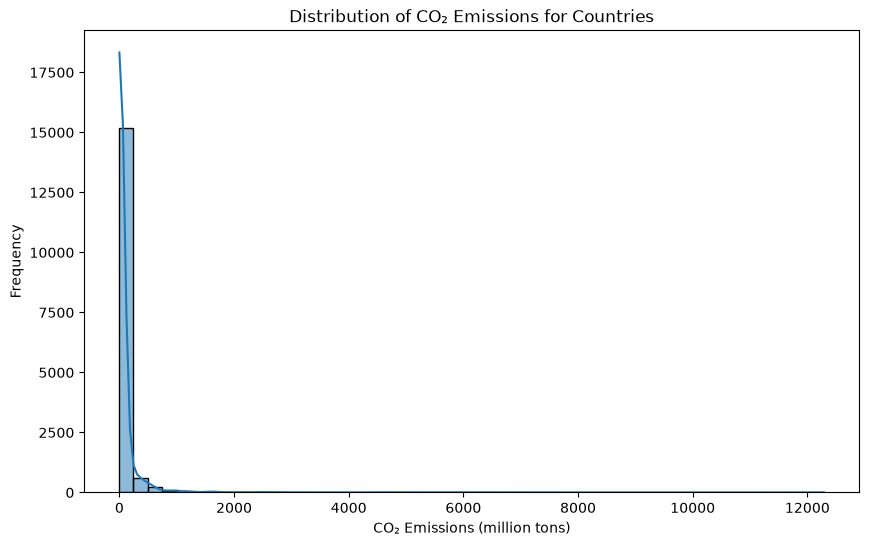

In [ ]:
# Plotting the distribution of CO2 emmissions for countries from df_countries dataset
plt.figure(figsize=(10,6))
sns.histplot(df_countries["co2"], bins=50, kde=True)
plt.title("Distribution of CO₂ Emissions for Countries")
plt.xlabel("CO₂ Emissions (million tons)")
plt.ylabel("Frequency")
plt.show()

Most countries occupy under 1000 million tons of CO2 Emission with high outliers over 10,000 million tons. 

In [85]:
# country with co2 emissions greater than 10000
df_countries_high_emission = df_countries[df_countries["co2"] > 11000]
df_countries_high_emission

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
9930,China,2021,CHN,1.426437e+09,2.618060e+13,802.485,0.563,11284.401,387.881,3.560,10996.103,363.265,3.416,7.709,0.420,250.782,7.911,0.431,257.358,8004.203,5.611,15289.931,248914.188,324403.344,187175.891,153.651,82622.836,34194.715,30738.947,4.812,0.003,8.790,9.085,-288.299,-0.202,1450.486,1.017,465.801,0.327,1521.109,1.066,43847.180,48.143,30.609,26.481,53.471,33.901,14.347,12.367,23.311,0.812,9.254,5.686,1.196,-6.191,13.212,12.285,0.049,0.139,0.197,0.009,12958.471,12538.149
9931,China,2022,CHN,1.425180e+09,2.696602e+13,718.777,0.504,11711.808,427.406,3.788,11414.117,418.015,3.801,8.009,0.423,256.402,8.218,0.434,263.089,8468.947,5.942,16008.708,260625.984,335817.438,195644.844,158.329,82325.141,35754.434,31235.707,4.678,0.003,9.144,9.435,-297.690,-0.209,1513.475,1.062,464.382,0.326,1559.721,1.094,44516.492,45.529,31.208,26.975,54.818,34.294,14.704,12.599,23.906,0.820,9.171,5.830,1.173,-6.221,13.090,12.507,0.050,0.144,0.204,0.009,13446.920,13031.949
9932,China,2023,CHN,1.422585e+09,3.224005e+10,681.688,0.479,12172.009,460.201,3.929,11859.866,445.749,3.905,8.337,0.641,251.952,8.556,0.266,258.583,8740.891,6.144,16690.396,272798.000,347677.312,204385.734,162.823,82012.992,37484.016,33089.070,4.494,0.003,9.513,9.795,-312.142,-0.219,1541.531,1.084,471.637,0.332,1729.580,1.216,47072.012,44.257,31.953,27.684,55.901,34.612,15.067,12.837,24.506,0.825,9.089,5.992,1.092,-6.578,14.087,12.731,0.051,0.150,0.211,0.010,13934.404,13532.396
9933,China,2024,CHN,1.419321e+09,3.224005e+10,617.752,0.435,12289.037,117.029,0.961,11969.620,109.753,0.925,8.433,0.641,244.342,8.658,0.266,250.863,8886.021,6.261,17308.148,285087.031,359646.906,213271.750,166.836,81693.578,39189.402,34514.457,4.013,0.003,9.651,9.939,-319.418,-0.225,1590.674,1.121,475.534,0.335,1705.386,1.202,48987.102,41.944,31.838,27.718,56.222,34.830,15.417,13.071,25.096,0.828,9.007,6.142,0.965,-6.966,13.675,12.951,0.053,0.155,0.217,0.010,14107.007,13698.566


China is the overall largest producer of CO2 in from their manufacturing, emissions and more especially in recent time.

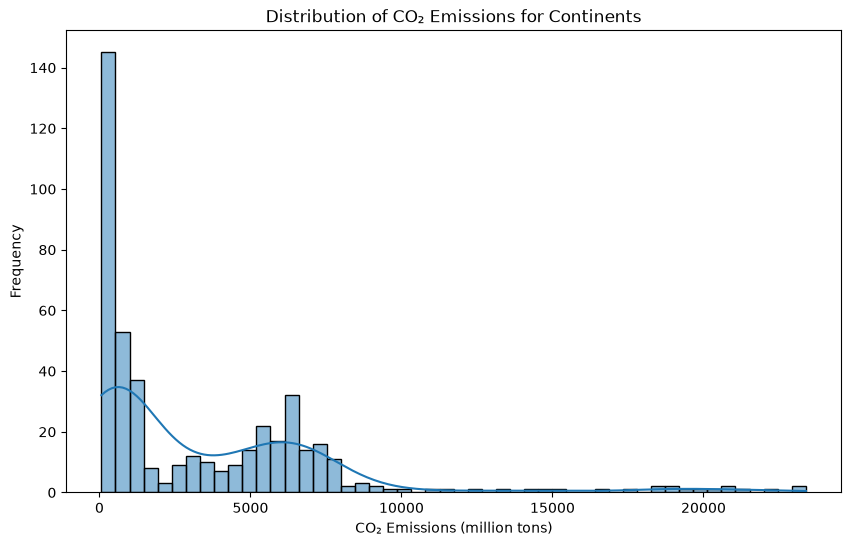

In [ ]:
# Plotting the distribution of CO2 emmissions for continents from df_continents dataset
plt.figure(figsize=(10,6))
sns.histplot(df_continents["co2"], bins=50, kde=True)
plt.title("Distribution of CO₂ Emissions for Continents")
plt.xlabel("CO₂ Emissions (million tons)")
plt.ylabel("Frequency")
plt.show()

There is a bias under 10000 CO2 emissions with few outlier continents producing over 20000 million tons of CO2.

In [87]:
# continents with co2 emissions greater than 20000
df_continents_high_emission = df_continents[df_continents["co2"] > 20000]
df_continents_high_emission


,country,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
2947,Asia,2018,4.612353e+09,1241.316,0.269,20366.350,590.512,2.986,21438.354,675.598,3.254,4.648,0.366,261.680,4.416,0.348,248.595,11161.663,2.420,23953.787,493868.719,756903.000,260315.203,6223.988,322406.719,146416.234,17801.225,117.414,0.025,5.051,5.846,1399.994,0.304,4254.552,0.922,1208.031,0.262,4739.622,1.028,82105.531,80.248,55.443,51.515,75.607,59.593,30.377,30.276,34.297,35.202,36.688,25.842,29.060,28.677,39.032,33.778,0.150,0.343,0.518,0.025,26961.553,23296.732
2948,Asia,2019,4.651099e+09,1305.078,0.281,20926.584,560.234,2.751,22104.678,666.325,3.108,4.753,0.363,262.135,4.499,0.344,248.164,11437.149,2.459,25258.867,514795.312,779007.688,271752.344,6332.816,323902.625,151293.391,18168.754,108.828,0.023,5.137,5.951,1495.906,0.322,4276.850,0.920,1216.375,0.262,4877.151,1.049,84504.664,80.773,56.426,52.663,77.788,60.412,30.958,30.646,35.124,34.962,36.655,26.134,25.169,30.609,39.568,34.123,0.153,0.353,0.532,0.026,27680.395,23893.223
2949,Asia,2020,4.686811e+09,1320.692,0.282,20691.949,-234.635,-1.121,21450.055,-654.623,-2.961,4.577,0.357,255.757,4.415,0.344,246.718,11443.860,2.442,26579.559,535487.250,800457.750,283196.188,6441.635,324967.719,155847.688,17940.240,108.819,0.023,5.039,5.782,1065.116,0.227,4275.868,0.912,1235.640,0.264,4554.286,0.972,84082.523,81.321,58.854,54.065,80.212,61.194,31.536,31.006,35.940,34.795,36.588,26.422,27.205,23.583,41.659,34.461,0.156,0.363,0.545,0.026,27097.293,23618.863
2950,Asia,2021,4.716999e+09,1339.035,0.284,21520.502,828.553,4.004,22183.609,733.555,3.420,4.703,0.346,251.395,4.562,0.336,243.880,11928.202,2.529,27918.592,557007.750,822641.375,295124.406,6556.944,325949.312,160522.203,18752.594,115.310,0.024,5.205,5.940,981.595,0.208,4377.963,0.928,1251.591,0.265,4674.532,0.991,88455.969,80.332,58.374,53.424,79.685,61.901,32.106,31.361,36.755,34.664,36.507,26.694,28.669,21.077,40.602,34.798,0.159,0.373,0.558,0.027,28018.820,24550.723
2951,Asia,2022,4.746330e+09,1257.734,0.265,22237.812,717.310,3.333,22752.574,568.963,2.565,4.794,0.341,251.146,4.685,0.333,245.464,12560.106,2.646,29176.328,579245.562,845393.875,307684.500,6668.508,326769.906,165403.953,19146.773,111.563,0.024,5.356,6.065,820.562,0.173,4533.146,0.955,1252.393,0.264,4881.739,1.029,90876.898,79.667,59.257,53.772,81.300,62.502,32.681,31.716,37.596,34.526,36.404,26.971,27.970,17.147,40.972,35.145,0.162,0.383,0.573,0.027,28784.645,25421.619
2952,Asia,2023,4.776660e+09,1221.227,0.256,22997.092,759.280,3.414,23594.170,841.597,3.699,4.939,0.641,250.402,4.814,0.266,244.065,13057.732,2.734,30397.555,602242.688,868988.062,320742.250,6786.952,327668.094,170500.094,19784.426,118.444,0.025,5.504,6.225,898.206,0.188,4626.225,0.96

Asia, matching China's recent trend, has an increasing emission of CO2 over the recent years.

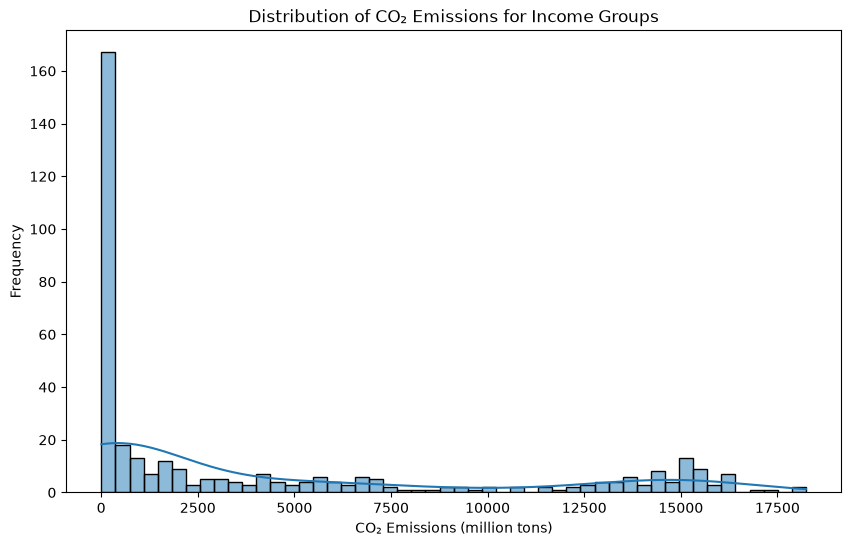

In [ ]:
# Plotting the distribution of CO2 emmissions for income groups from df_income_groups dataset
plt.figure(figsize=(10,6))
sns.histplot(df_income_groups["co2"], bins=50, kde=True)
plt.title("Distribution of CO₂ Emissions for Income Groups")
plt.xlabel("CO₂ Emissions (million tons)")
plt.ylabel("Frequency")
plt.show()

There is a spike of low co2 emission in income groups with a slightly bimodal distribution.  

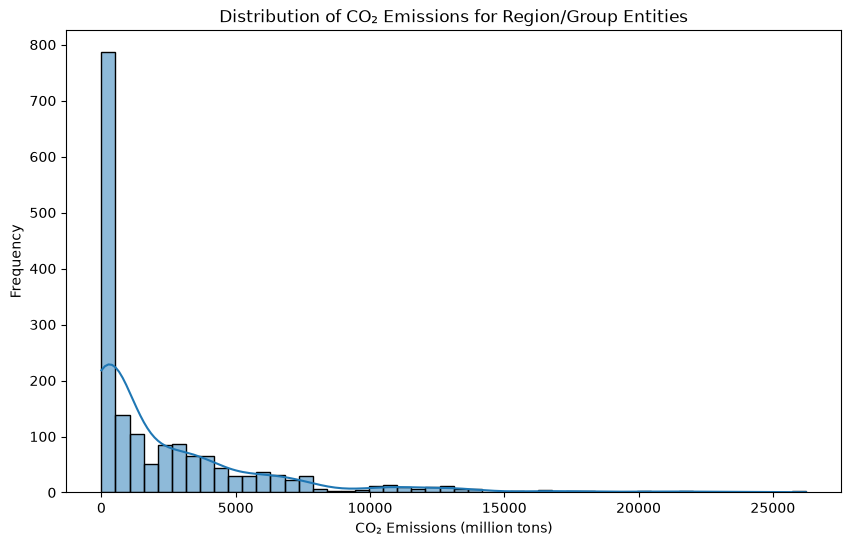

In [ ]:
# Plotting the distribution of CO2 emmissions for religious/group entities from df_region_group_entities dataset
plt.figure(figsize=(10,6))
sns.histplot(df_region_group_entities["co2"], bins=50, kde=True)
plt.title("Distribution of CO₂ Emissions for Region/Group Entities")
plt.xlabel("CO₂ Emissions (million tons)")
plt.ylabel("Frequency")
plt.show()

There is a bias under 10000 million tons CO2 emissions with few outlier Entities producing over 20000 million tons of CO2.

In [90]:
# Entities with co2 emissions greater than 25000
df_region_group_entities_high_emissions = df_region_group_entities[df_region_group_entities["co2"] > 25000]
df_region_group_entities_high_emissions

,country,year,population,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_luc_co2,cumulative_oil_co2,energy_per_capita,flaring_co2,flaring_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_flaring_co2,share_global_luc_co2,share_global_oil_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf
33559,Non-OECD (GCP),2023,4466330.0,0.228,0.035,25758.965,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747
33560,Non-OECD (GCP),2024,4466330.0,0.228,0.035,26233.051,0.058,3.175,29.588,0.04,1.0705,4.499,0.641,282.23,2.147,0.266,220.8685,2.367,0.285,3.956,156.9055,1295.9315,96.147,0.348,777.166,82.6305,11792.955,0.002,0.001,2.2945,5.966,3.434,0.702,8.9415,1.155,2.8925,0.357,3.624,1.112,58.186,0.045,0.033,0.108,0.028,0.041,0.02,0.09,0.021,0.004,0.111,0.038,0.001,0.053,0.048,0.094,0.0,0.0,0.001,0.0,40.859,12.747


Non-OECD (GCP) is the highest pollutant. Especially in recent years.

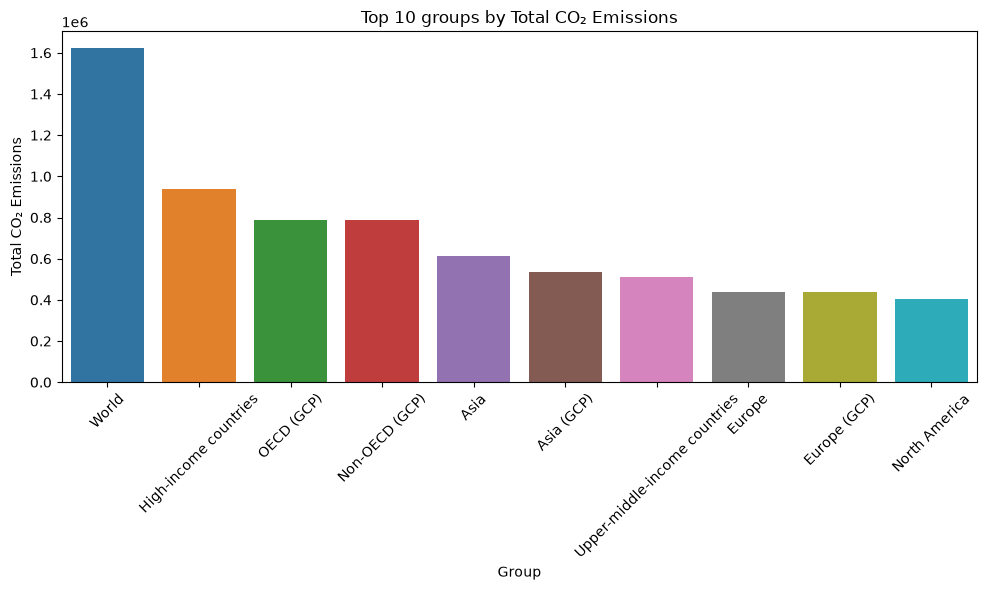

In [ ]:
top_emitters = df_cleaned.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 overall groups by Total CO₂ Emissions")
plt.xlabel("Group")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This provides an overall ranking of CO2 emission in the whole dataset without separating it into groups.

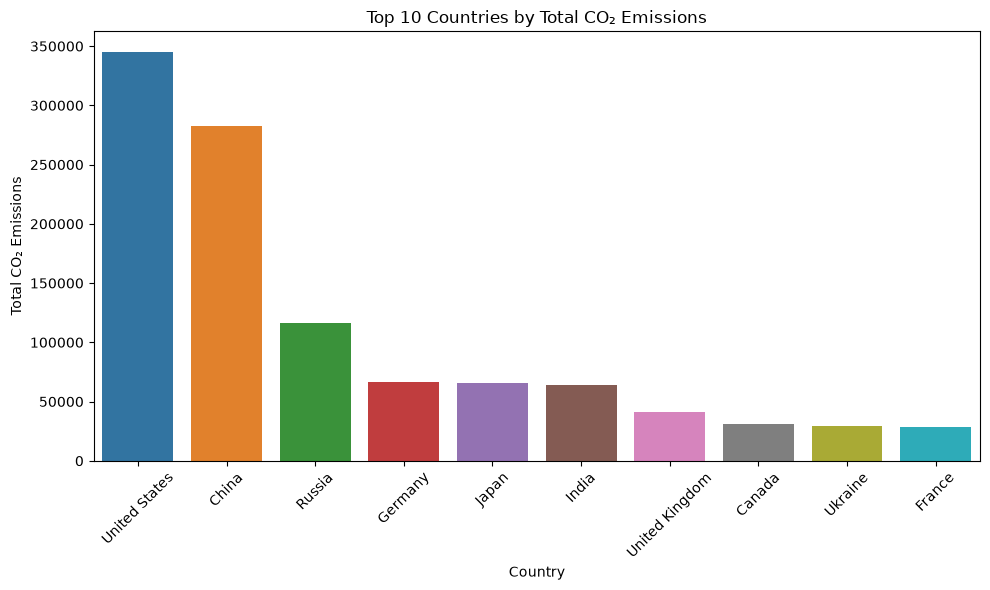

In [92]:
top_emitters = df_countries.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The United States has the highest emissions; followed by China and Russia 

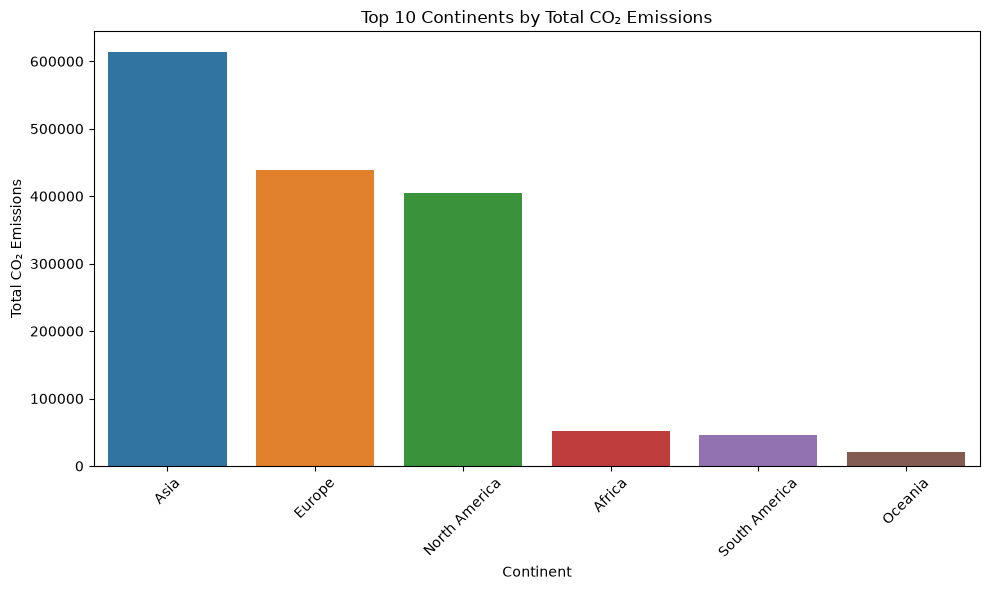

In [93]:
top_emitters = df_continents.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Continents by Total CO₂ Emissions")
plt.xlabel("Continent")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Asia is the biggest polluting continent. 

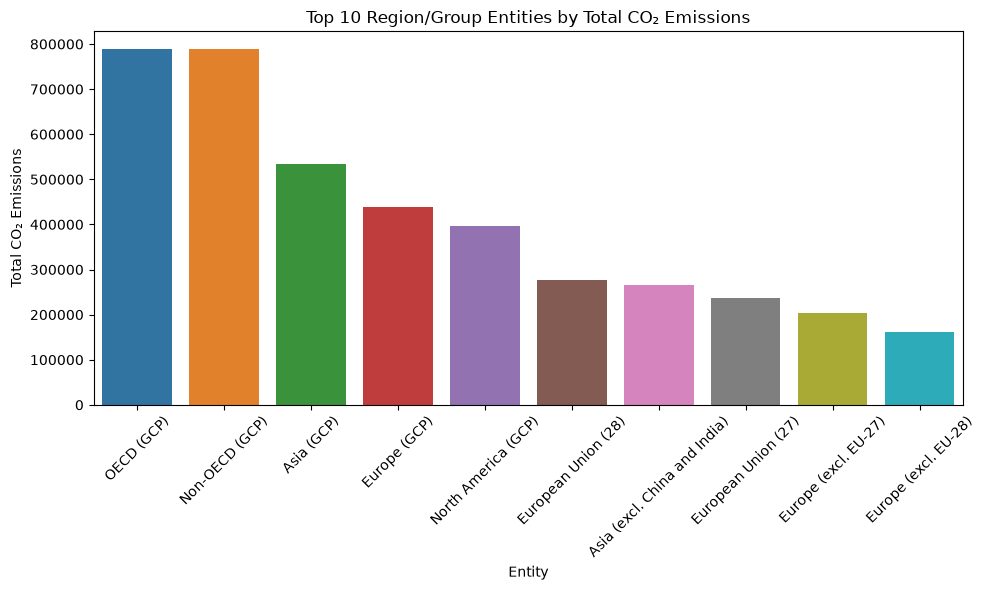

In [94]:
top_emitters = df_region_group_entities.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Region/Group Entities by Total CO₂ Emissions")
plt.xlabel("Entity")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

OECD are the highest polluter in the Region/Group entities dataset.


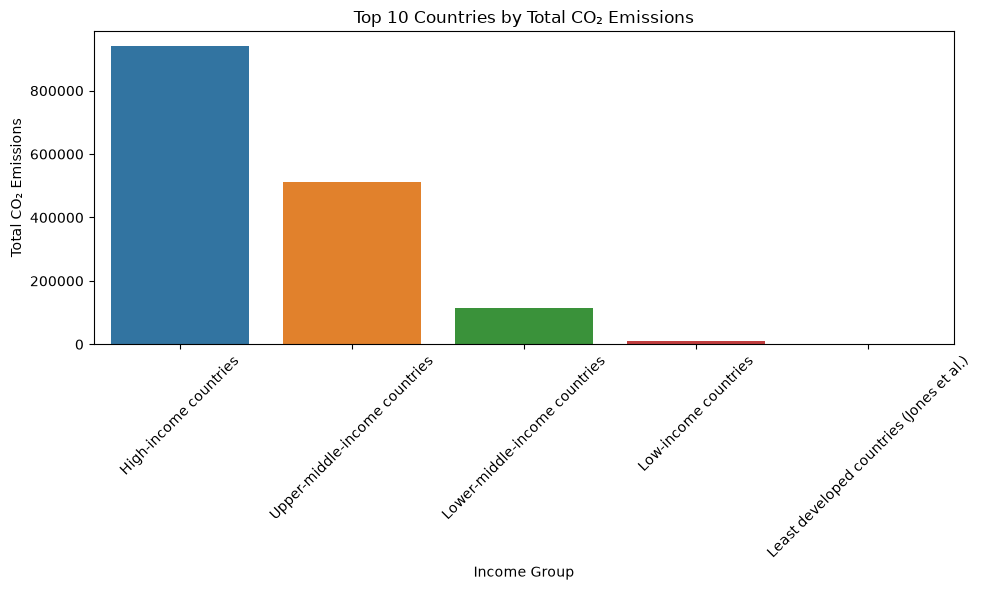

In [95]:
top_emitters = df_income_groups.groupby("country")["co2"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Income Group")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see the higher the income the higher the pollution. High income countries pollute our environment the most.


## Economic

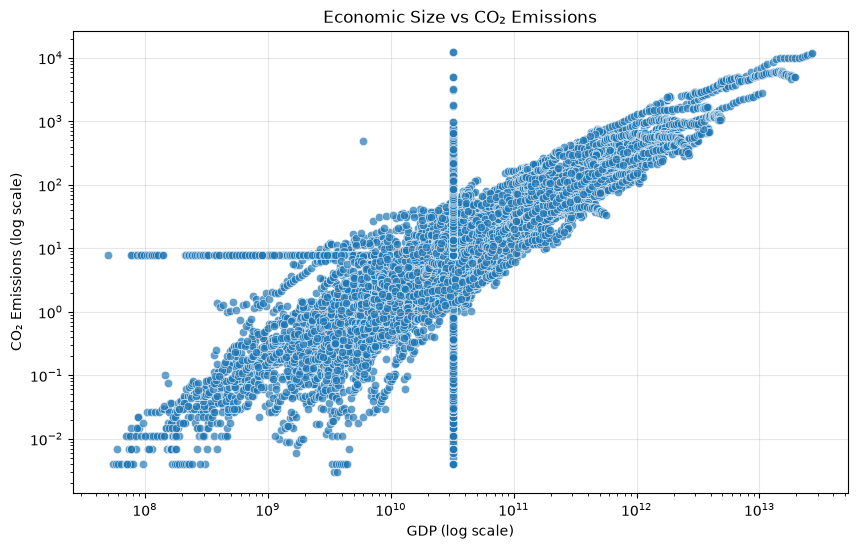

In [ ]:
# Plotting a comparision between economic size and CO2 emissions from df_countries
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_countries,
    x="gdp",
    y="co2",
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Economic Size vs CO₂ Emissions")
plt.xlabel("GDP (log scale)")
plt.ylabel("CO₂ Emissions (log scale)")
plt.grid(True, alpha=0.3)

plt.show()

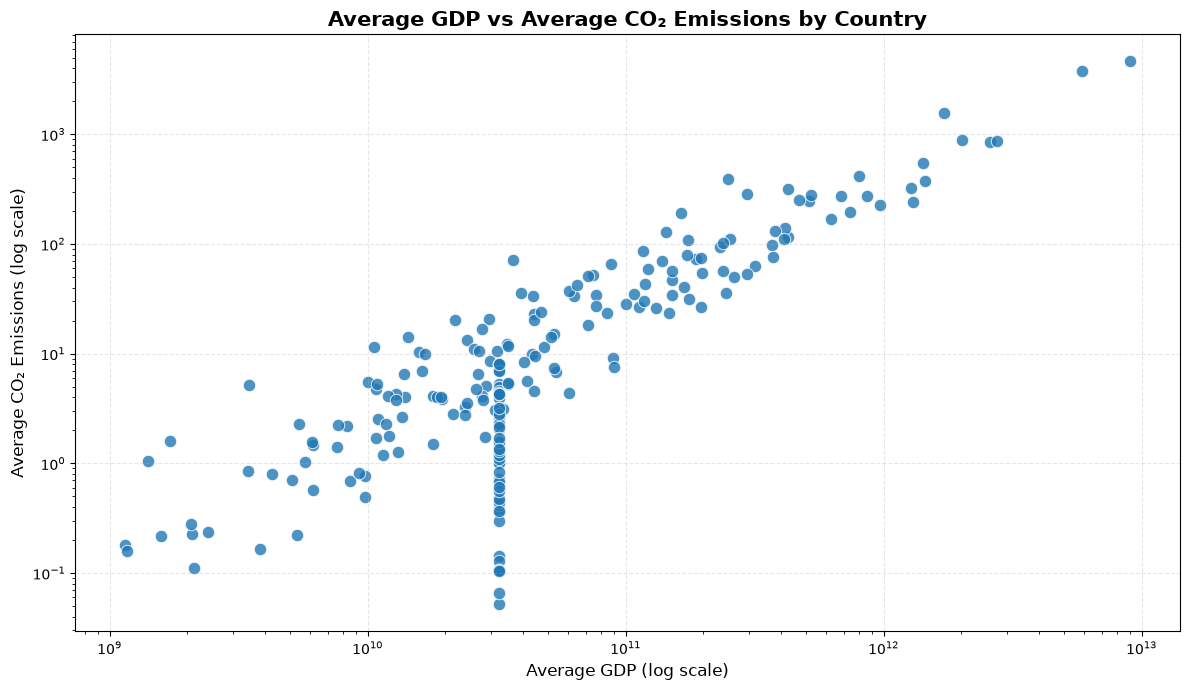

In [ ]:
# Calculate average GDP and CO₂ emissions for each country
country_avg = (
    df_countries.groupby("country", as_index=False)
    .agg({
        "gdp": "mean",
        "co2": "mean"
    })
)

# Create the scatter plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=country_avg,
    x="gdp",
    y="co2",
    s=80,
    alpha=0.8
)

# Log scales for better visualization
plt.xscale("log")
plt.yscale("log")

plt.title("Average GDP vs Average CO₂ Emissions by Country", fontsize=15, weight="bold")
plt.xlabel("Average GDP (log scale)", fontsize=12)
plt.ylabel("Average CO₂ Emissions (log scale)", fontsize=12)

plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.grid(True)
plt.show()

We see a positive relationship between GDP and CO2 Emissions. (The higher the gdp, the higher the Emission)

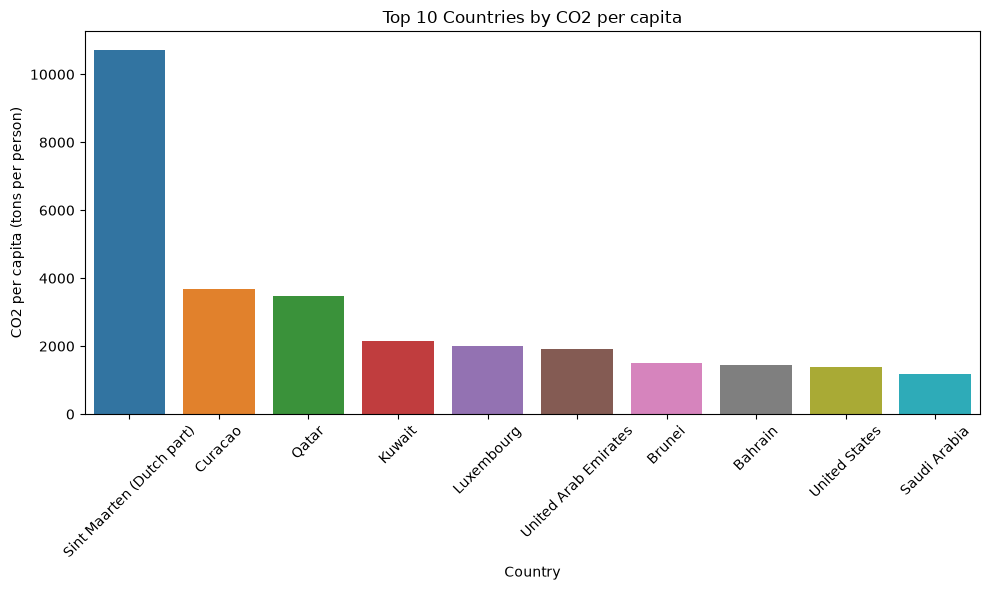

In [98]:
# co2_per_capita vs country
top_emitters = df_countries.groupby("country")["co2_per_capita"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by CO2 per capita")
plt.xlabel("Country")
plt.ylabel("CO2 per capita (tons per person)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sint Maarten (Dutch part) has the highest CO2 production in industralization and burning of fossil fuels.

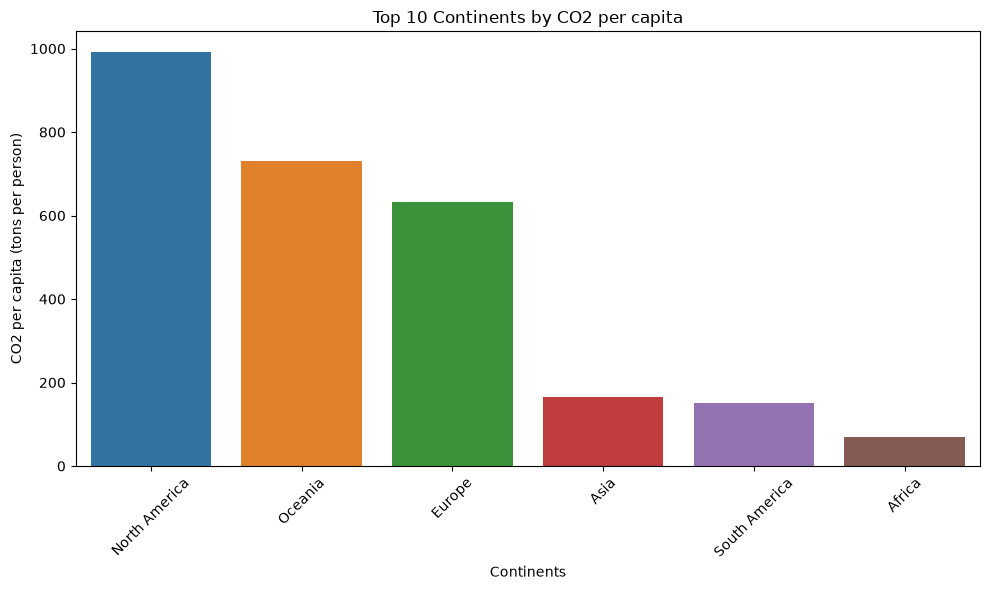

In [99]:
# co2_per_capita vs country
top_emitters = df_continents.groupby("country")["co2_per_capita"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Continents by CO2 per capita")
plt.xlabel("Continents")
plt.ylabel("CO2 per capita (tons per person)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

North America has the highest CO2 production in industralization and burning of fossil fuels.

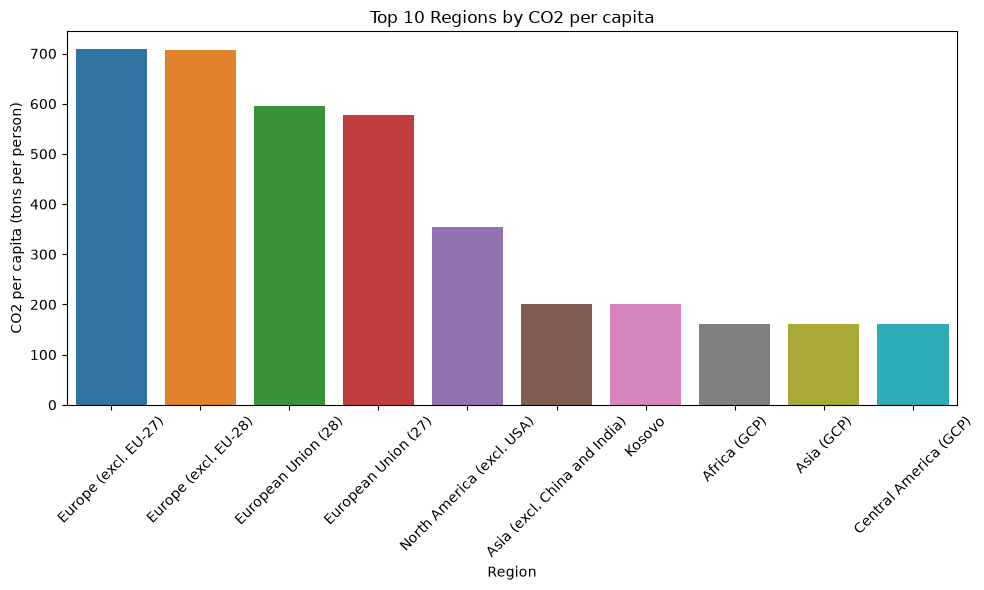

In [100]:
# co2_per_capita vs country
top_emitters = df_region_group_entities.groupby("country")["co2_per_capita"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Regions by CO2 per capita")
plt.xlabel("Region")
plt.ylabel("CO2 per capita (tons per person)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Europe has the occupied the majority of CO2 production in industralization and burning of fossil fuels.

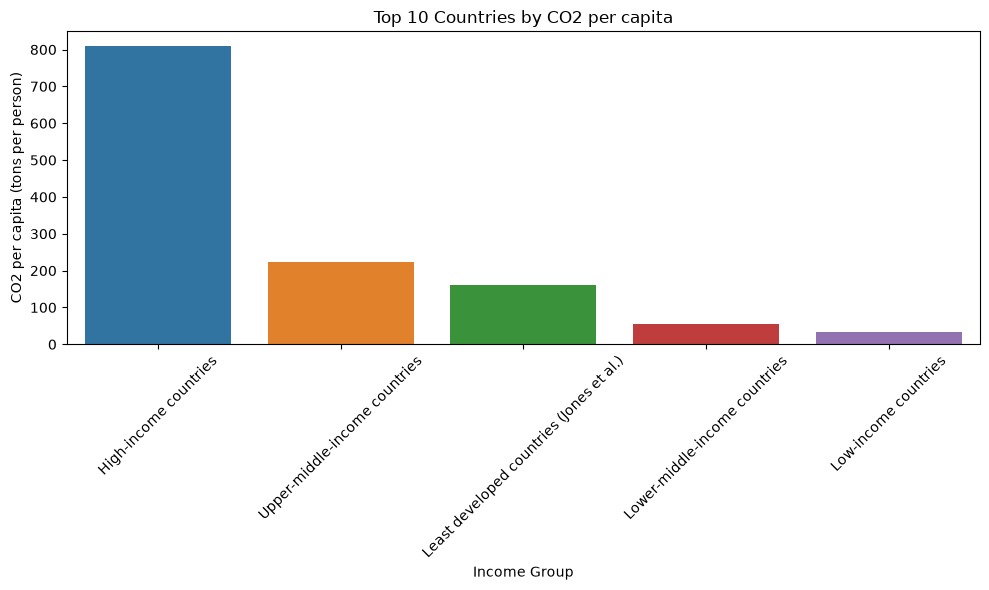

In [101]:
# co2_per_capita vs country
top_emitters = df_income_groups.groupby("country")["co2_per_capita"].sum().nlargest(10)

# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    hue=top_emitters.index,
    palette=country_colors
)

plt.title("Top 10 Countries by CO2 per capita")
plt.xlabel("Income Group")
plt.ylabel("CO2 per capita (tons per person)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

High-income countries have the highest CO2 production in industralization and burning of fossil fuels. The higher the income the higher the CO2 production. 

## Demographic


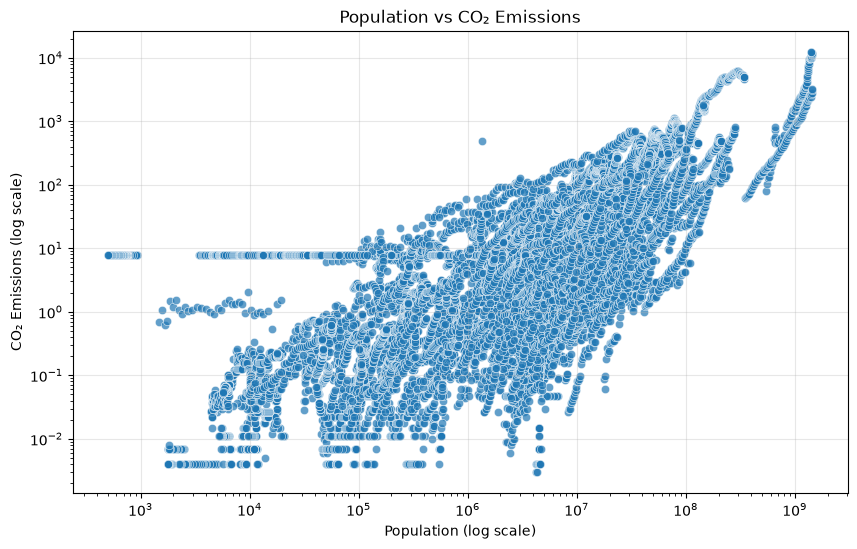

In [102]:
# plot of co2 against population
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_countries,
    x="population",
    y="co2",
    alpha=0.7
)
plt.xscale("log")
plt.yscale("log")

plt.title("Population vs CO₂ Emissions")
plt.xlabel("Population (log scale)")
plt.ylabel("CO₂ Emissions (log scale)")
plt.grid(True, alpha=0.3)
plt.show()

The higher the population the higher the co2 emissions but effects become significant when population crosses the 10^6.

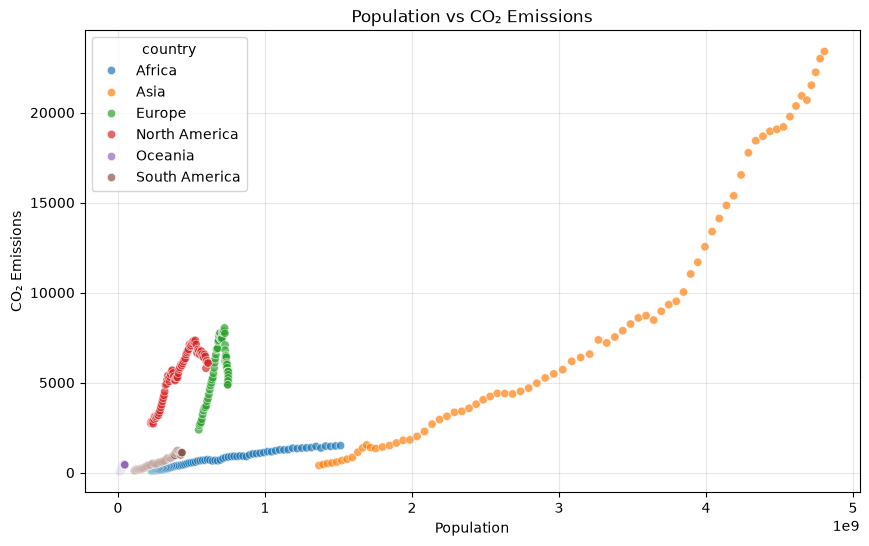

In [103]:
# plot of co2 against population
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_continents,
    x="population",
    y="co2",
    alpha=0.7,
    hue = "country"
)

plt.title("Population vs CO₂ Emissions")
plt.xlabel("Population")
plt.ylabel("CO₂ Emissions")
plt.grid(True, alpha=0.3)
plt.show()

The higher the population the higher the co2 emissions with Asia having the steepest climb.

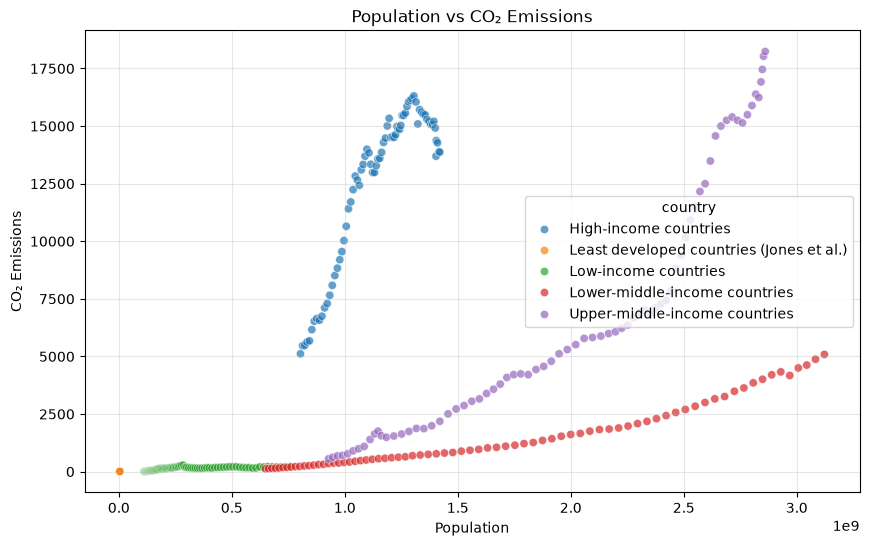

In [104]:
# plot of co2 against population
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_income_groups,
    x="population",
    y="co2",
    alpha=0.7,
    hue = "country"
)

plt.title("Population vs CO₂ Emissions")
plt.xlabel("Population")
plt.ylabel("CO₂ Emissions")
plt.grid(True, alpha=0.3)
plt.show()

The higher the population the higher the co2 emissions in all relevant data subsets.

## Energy related variables

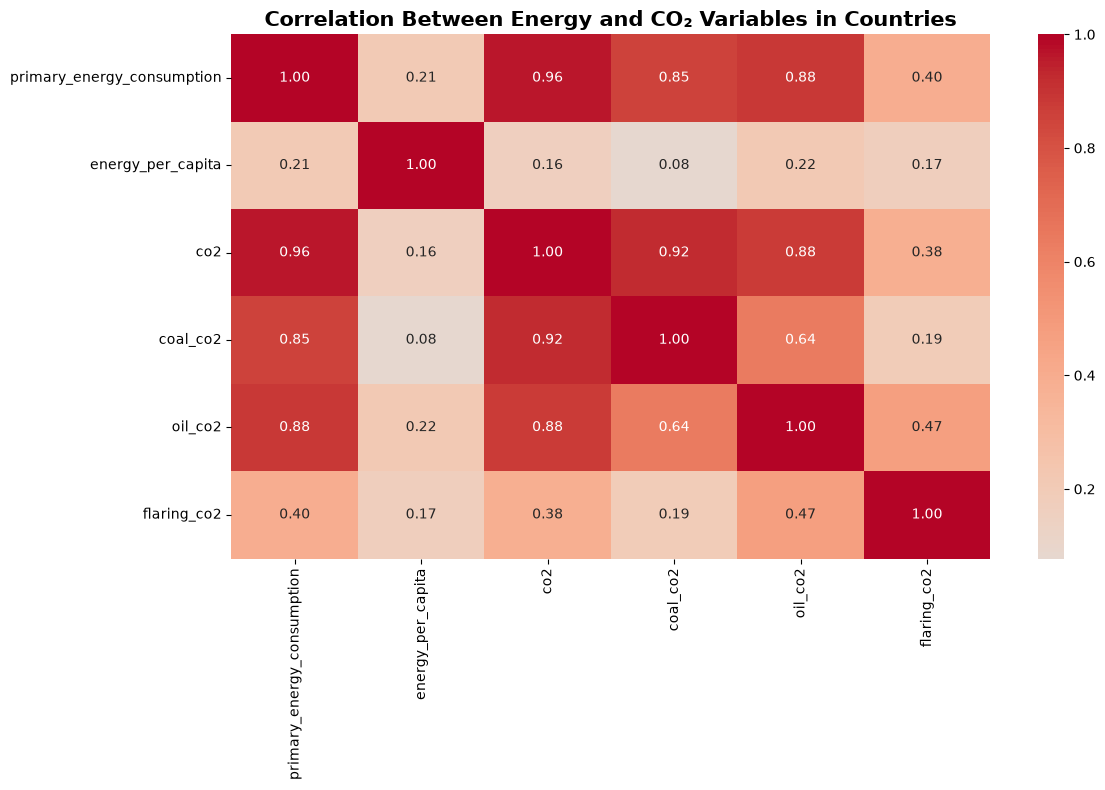

In [105]:
energy_vars = [
    "primary_energy_consumption",
    "energy_per_capita",
    "co2",
    "coal_co2",
    "oil_co2",
    "flaring_co2"
]

corr = df_countries[energy_vars].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Energy and CO₂ Variables in Countries",
          fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

The highest correlation is between primary_energy_consumption and co2, while the lowest correlation is energy_per_capita and co2

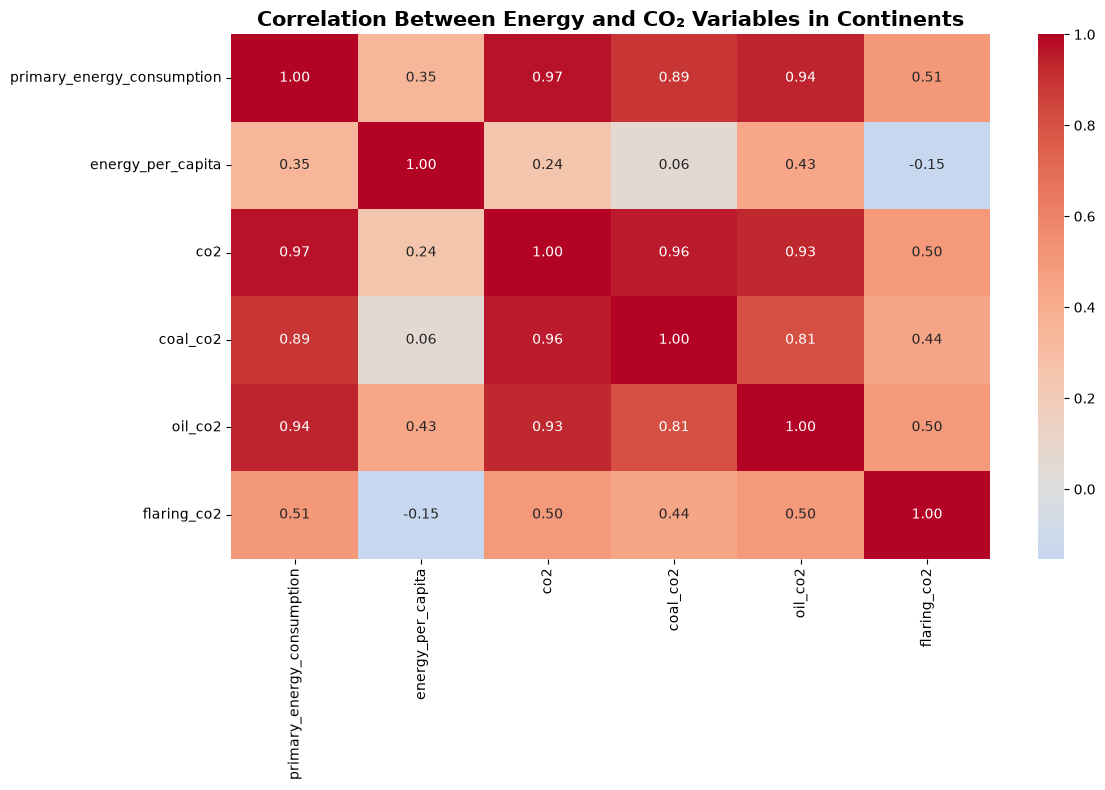

In [106]:
energy_vars = [
    "primary_energy_consumption",
    "energy_per_capita",
    "co2",
    "coal_co2",
    "oil_co2",
    "flaring_co2"
]

corr = df_continents[energy_vars].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Energy and CO₂ Variables in Continents",
          fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

The highest correlation is between primary_energy_consumption and co2, while the lowest is energy_per_capita and coal_co2

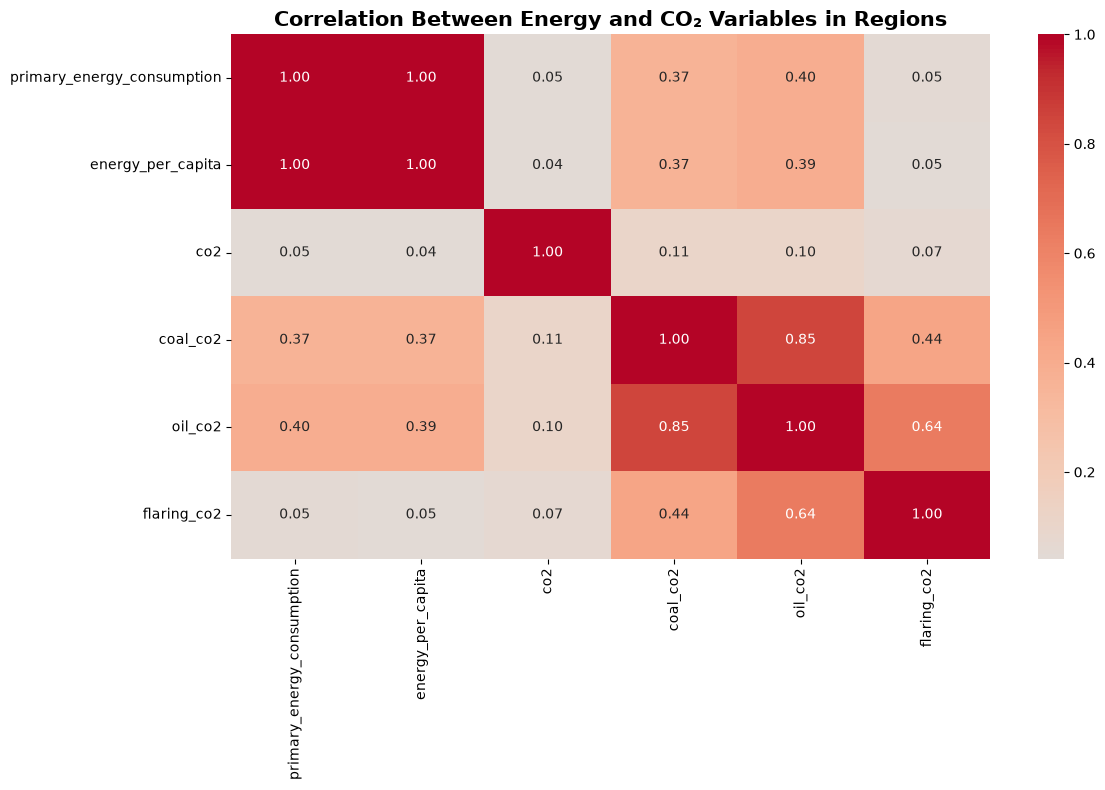

In [107]:
energy_vars = [
    "primary_energy_consumption",
    "energy_per_capita",
    "co2",
    "coal_co2",
    "oil_co2",
    "flaring_co2"
]

corr = df_region_group_entities[energy_vars].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Energy and CO₂ Variables in Regions",
          fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

Very high correlation between primary_energy_consuption and energy_per_capita

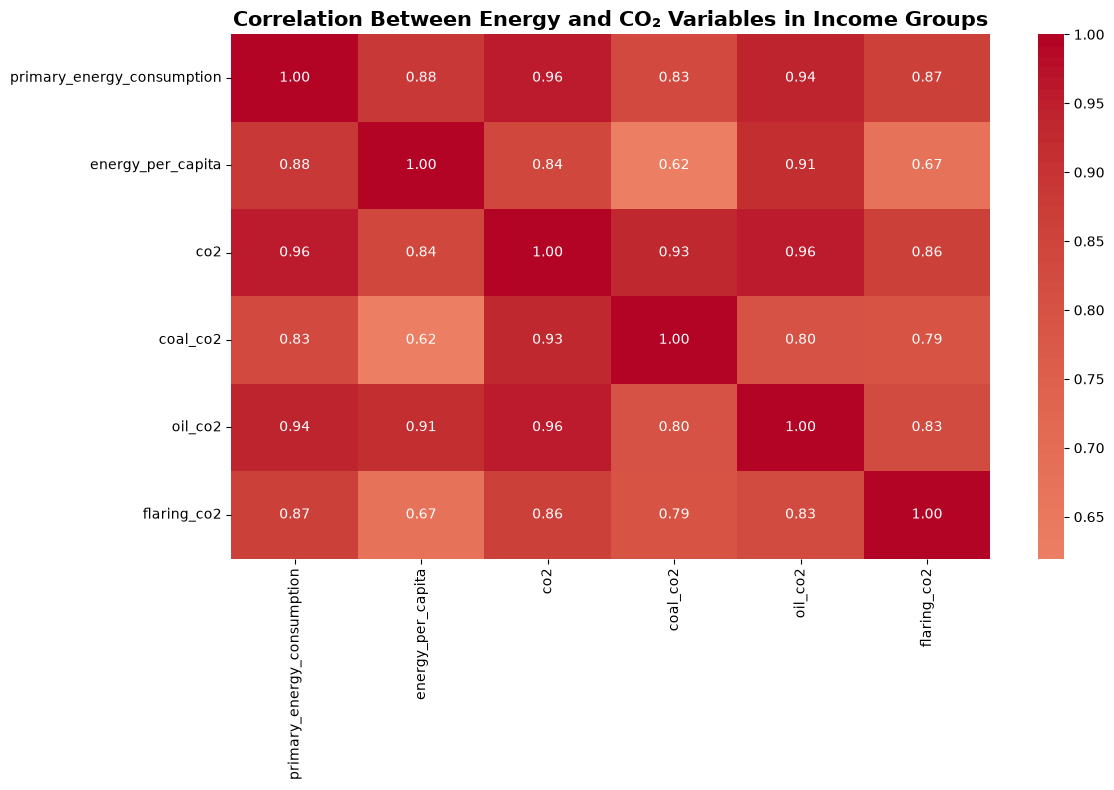

In [108]:
energy_vars = [
    "primary_energy_consumption",
    "energy_per_capita",
    "co2",
    "coal_co2",
    "oil_co2",
    "flaring_co2"
]

corr = df_income_groups[energy_vars].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Energy and CO₂ Variables in Income Groups",
          fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

High correlation is observed throughout the features selected.


The highest cumulative emitters (China) for a large share of total historical CO2, but their trajectories differ across decades. 
This supports country segmentation by trend behavior, not only absolute emission totals.


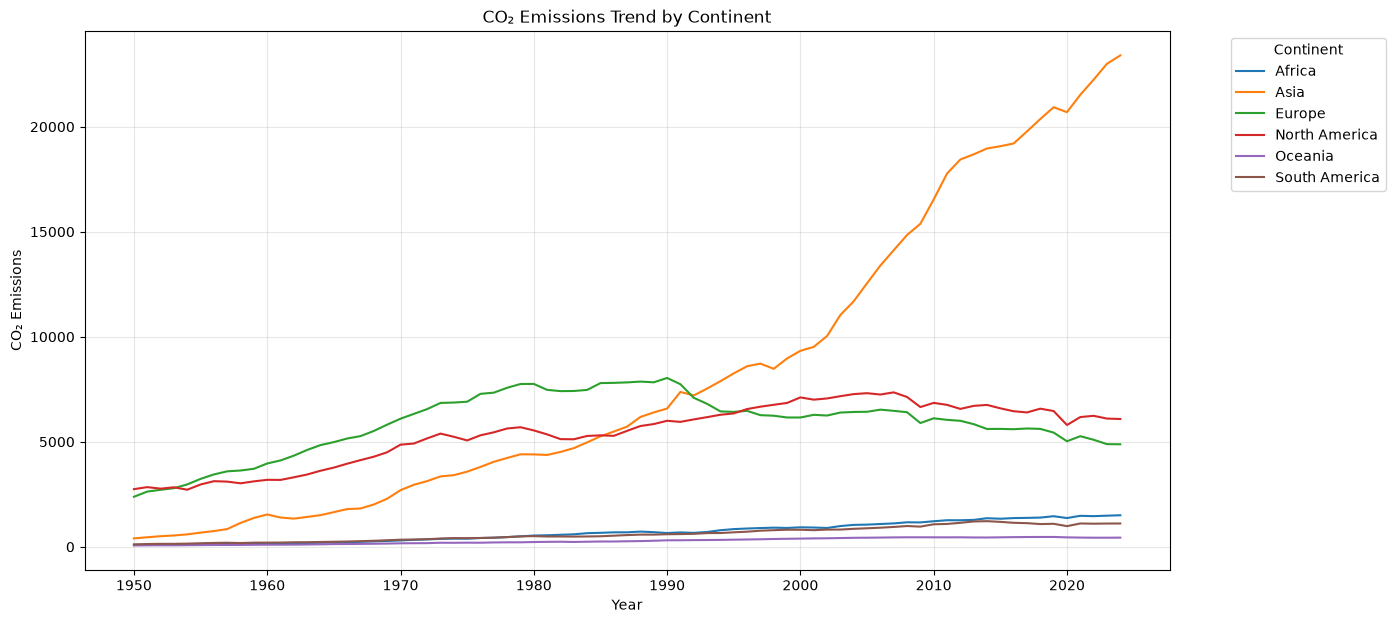

In [110]:
# CO₂ emissions trend by continent

continent_trend = (
    df_continents
    .groupby(["year", "country"])["co2"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=continent_trend,
    x="year",
    y="co2",
    hue="country"
)

plt.title("CO₂ Emissions Trend by Continent")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True, alpha=0.3)
plt.show()

co2 emmissions over time

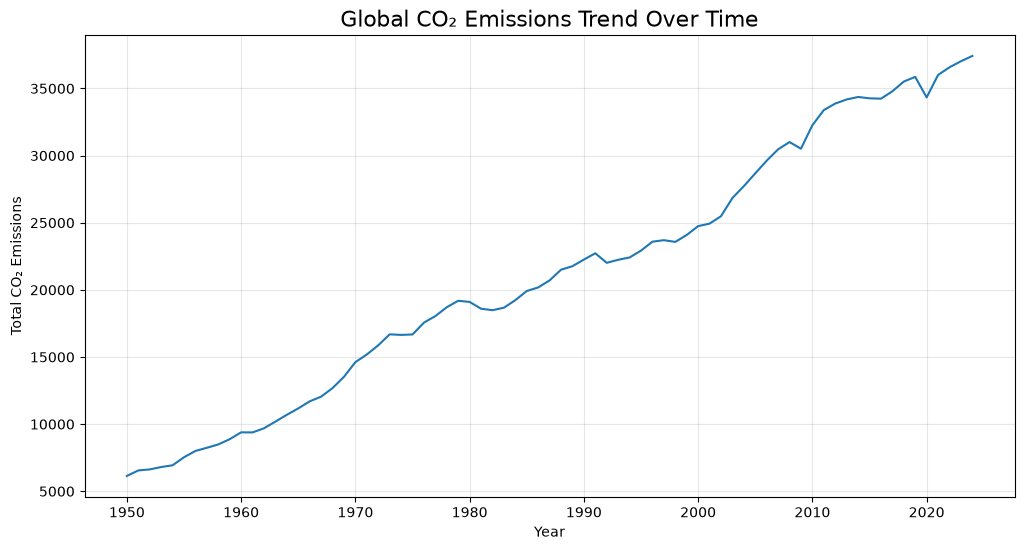

In [111]:
# Trend analysis of CO₂ emissions over time

# Calculate total CO₂ emissions for each year
yearly_co2 = df_countries.groupby("year")["co2"].sum().reset_index()

# Plot the trend
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_co2,
    x="year",
    y="co2"
)

plt.title("Global CO₂ Emissions Trend Over Time", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total CO₂ Emissions")
plt.grid(True, alpha=0.3)

plt.show()

Global CO2 levels generally move upward over time, with intermittent periods of slower growth or temporary decline.


In [112]:
# Calculate year-on-year percentage change

yearly_co2["co2_growth"] = yearly_co2["co2"].pct_change() * 100

yearly_co2.tail()

,year,co2,co2_growth
70,2020,34334.126,-4.261769
71,2021,36002.866,4.860296
72,2022,36577.434,1.595895
73,2023,37026.972,1.229004
74,2024,37421.965,1.066771


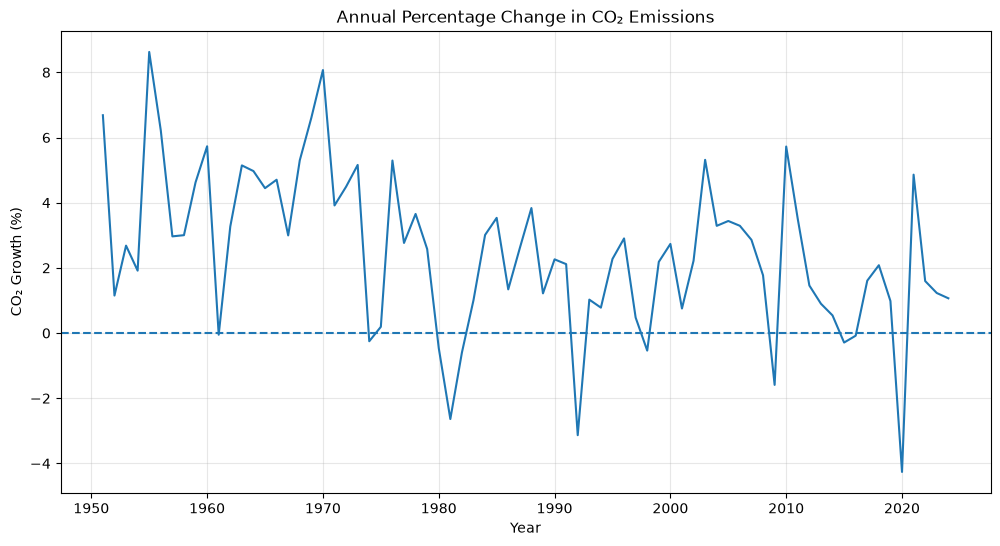

In [113]:
# Plot annual CO₂ growth rate

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_co2,
    x="year",
    y="co2_growth"
)

plt.axhline(0, linestyle="--")

plt.title("Annual Percentage Change in CO₂ Emissions")
plt.xlabel("Year")
plt.ylabel("CO₂ Growth (%)")
plt.grid(True, alpha=0.3)

plt.show()

The growth-rate view helps isolate momentum changes useful for forecasting assumptions.

## Modeling

### Base Model

In [114]:
# from pathlib import Path

# import numpy as np
# import pandas as pd
# from sklearn.cluster import KMeans
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import silhouette_score
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler

# # Build modeling table from the country-level dataset.
# if "df_countries" in globals():
#     model_df = df_countries.copy()
# elif "df" in globals():
#     model_df = df[df["iso_code"].str.len() == 3].copy()
# else:
#     raise ValueError("No dataset found. Run the data loading and cleaning cells first.")

# if "year" in model_df.columns:
#     latest_year = int(model_df["year"].max())
#     model_df = model_df[model_df["year"] == latest_year].copy()
#     print(f"Using latest year snapshot for clustering: {latest_year}")

# candidate_features = [
#     "co2_per_capita",
#     "co2_growth_prct",
#     "gdp",
#     "population",
#     "primary_energy_consumption",
#     "energy_per_capita",
#     "energy_intensity",
#     "carbon_intensity_elec",
#     "coal_co2",
#     "oil_co2",
#     "gas_co2",
#     "cement_co2",
#     "flaring_co2",
#     "trade_co2",
#     "methane",
#     "nitrous_oxide",
#     "renewables_share_energy",
#     "fossil_share_energy",
# ]

# available_features = [c for c in candidate_features if c in model_df.columns]
# if len(available_features) < 5:
#     raise ValueError(
#         f"Not enough features found for clustering. Available: {available_features}"
#     )

# X = model_df[available_features].copy()
# numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
# categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             "num",
#             Pipeline(steps=[
#                 ("imputer", SimpleImputer(strategy="median")),
#                 ("scaler", StandardScaler()),
#             ]),
#             numeric_features,
#         ),
#         (
#             "cat",
#             Pipeline(steps=[
#                 ("imputer", SimpleImputer(strategy="most_frequent")),
#                 ("onehot", OneHotEncoder(handle_unknown="ignore")),
#             ]),
#             categorical_features,
#         ),
#     ]
# )

# X_prepared = preprocessor.fit_transform(X)

# # Evaluate cluster counts and select k by silhouette score.
# k_values = range(2, 9)
# k_eval_rows = []
# for k in k_values:
#     km = KMeans(n_clusters=k, random_state=42, n_init=20)
#     labels = km.fit_predict(X_prepared)
#     sil = silhouette_score(X_prepared, labels)
#     k_eval_rows.append({
#         "k": k,
#         "silhouette": sil,
#         "inertia": km.inertia_,
#     })

# k_eval_df = pd.DataFrame(k_eval_rows).sort_values("k")
# display(k_eval_df)

# best_k = int(k_eval_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
# print(f"Selected k = {best_k} (highest silhouette score).")

# final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
# model_df["cluster"] = final_kmeans.fit_predict(X_prepared)

# cluster_profile = (
#     model_df.groupby("cluster")[available_features]
#     .median()
#     .round(3)
#     .sort_index()
# )
# print("Cluster profile (median values):")
# display(cluster_profile)

# if "country" in model_df.columns:
#     country_cluster_map = model_df[["country", "cluster"]].drop_duplicates().sort_values("country")
# else:
#     country_cluster_map = model_df[["cluster"]].copy()

# print("Sample country-to-cluster mapping:")
# display(country_cluster_map.head(20))

# output_dir = Path("outputs")
# output_dir.mkdir(exist_ok=True)
# cluster_profile.to_csv(output_dir / "cluster_profile_latest_year.csv")
# country_cluster_map.to_csv(output_dir / "country_cluster_mapping_latest_year.csv", index=False)
# k_eval_df.to_csv(output_dir / "cluster_k_evaluation.csv", index=False)

# print("Saved files:")
# print("- outputs/cluster_profile_latest_year.csv")
# print("- outputs/country_cluster_mapping_latest_year.csv")
# print("- outputs/cluster_k_evaluation.csv")

## Evaluation

## Deployment